In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


# How this will work:

We demonstrate with 5 words:

## Building the Dataset

Below, we use a context length of size 3 to predict the next character.

In [16]:
# build the dataset

block_size = 3 # context length, amount of characters used to predict next one
X, Y = [], []
for w in words[:5]:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)

... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
... ---> a
..a ---> v
.av ---> a
ava ---> .
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [17]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [18]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

Thus we have 32 examples to train our model on.

## Creating the Network
![Bengio Network](images/bengio-network.jpg)

In [58]:
# Each letter is assigned in an embedding space of two dimensions
C = torch.randn((27, 2))

In [20]:
# Get the point for each letter

emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [21]:
# This is our hidden layer

W1 = torch.randn((2 * 3, 100))
b1 = torch.randn(100)

# We want to do emb @ W1 + b1
# however emb is 32 x 3 x 2, which won't work, and we need to concat the 3x2 together

### Shape Problem

We want to perform `emb @ W1 + b1`, but `emb` has a shape of $32 \times 3 \times 2$ while `W1` has shape $6\times 100$.

Thus we need to find a way to concat the subarrays in dimension 1 to just an array. ($[[1, 4], [3, 2], [5,6]] \rightarrow [1, 4, 3, 2, 5, 6]$)

We demonstrate a few solutions:

In [22]:
# we want to concat over dimension 1. This does not generalize if we changed the block_size
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape 

torch.Size([32, 6])

In [23]:
torch.cat(torch.unbind(emb, 1), 1).shape


torch.Size([32, 6])

In [24]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [25]:
a.shape

torch.Size([18])

In [26]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [27]:
emb.view(32, 6)

tensor([[ 0.4884, -0.3975,  0.4884, -0.3975,  0.4884, -0.3975],
        [ 0.4884, -0.3975,  0.4884, -0.3975,  0.6305, -0.5003],
        [ 0.4884, -0.3975,  0.6305, -0.5003, -1.5915,  0.6200],
        [ 0.6305, -0.5003, -1.5915,  0.6200, -1.5915,  0.6200],
        [-1.5915,  0.6200, -1.5915,  0.6200, -0.3514, -0.6359],
        [ 0.4884, -0.3975,  0.4884, -0.3975,  0.4884, -0.3975],
        [ 0.4884, -0.3975,  0.4884, -0.3975,  0.6176, -0.1074],
        [ 0.4884, -0.3975,  0.6176, -0.1074, -0.7834, -2.4711],
        [ 0.6176, -0.1074, -0.7834, -2.4711, -0.3751, -0.7715],
        [-0.7834, -2.4711, -0.3751, -0.7715,  2.8437, -0.8223],
        [-0.3751, -0.7715,  2.8437, -0.8223, -0.3751, -0.7715],
        [ 2.8437, -0.8223, -0.3751, -0.7715, -0.3514, -0.6359],
        [ 0.4884, -0.3975,  0.4884, -0.3975,  0.4884, -0.3975],
        [ 0.4884, -0.3975,  0.4884, -0.3975, -0.3514, -0.6359],
        [ 0.4884, -0.3975, -0.3514, -0.6359,  2.8437, -0.8223],
        [-0.3514, -0.6359,  2.8437, -0.8

In [28]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [29]:
h.shape

torch.Size([32, 100])

In [30]:
h

tensor([[-0.9977,  0.9414, -0.3100,  ...,  0.3913,  0.5787, -0.9203],
        [-0.9984,  0.9437, -0.2659,  ...,  0.3824,  0.4389, -0.8832],
        [-0.8919,  0.8866, -0.9156,  ...,  0.4810,  0.9993, -0.9994],
        ...,
        [ 0.9483, -0.8262,  0.9926,  ...,  0.9704, -0.4982, -0.9828],
        [ 0.9847, -0.9893, -0.9893,  ...,  0.9982,  0.9994,  0.9920],
        [-0.5786, -0.7629, -0.9982,  ...,  0.9817,  0.9959,  0.8325]])

In [31]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [32]:
logits = h @ W2 + b2

In [33]:
logits.shape

torch.Size([32, 27])

In [34]:
counts = logits.exp()

In [35]:
prob = counts/ counts.sum(1, keepdims = True)

In [36]:
prob.shape

torch.Size([32, 27])

In [37]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [38]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.2365)

### Cross-Entropy

We use cross entropy instead of calculating the softmax and log likelihood directly because
1. Faster to calculate, as it uses fused kernels. This improves the forward pass.
2. The backward pass can be mathematically more efficient. For example, while tanh can be defined as a series of exponentials, it is faster to group it as tanh because the derivative of tanh is easier to calculate then going through the exponentials. This improves the backward pass.
3. It is more numerically well-behaved.

Numerically well-behaved:

If $x$ is a large number, $e^x$ may be a super large number. It turns out that we can add or subtract constants within our logits to have the same end probability.

This may be what is done inside pytorch.

In [49]:
logits = torch.tensor([ -5, -3, 0, 5, 100]) # can add or subtract constants, it is just large numbers dont behave well as e^x grows very fast
counts = logits.exp()
probs = counts/ counts.sum()
print(probs)
print("----------------")
logits = logits - 50
counts = logits.exp()
probs = counts/ counts.sum()
print(probs)
print("----------------")
logits = logits - 20
counts = logits.exp()
probs = counts/ counts.sum()
print(probs)

tensor([0., 0., 0., 0., nan])
----------------
tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 5.5211e-42, 1.0000e+00])
----------------
tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 5.5211e-42, 1.0000e+00])


### Minibatches:

Often times it is better to make multiple inaccurate steps faster than one accurate step but in a long time period.

Thus, during the training step, we can employ minibatches, which only train the network on a small random subset of the total dataset.

In [102]:
# Minibatchb
torch.randint(0, X.shape[0], (32,))

tensor([17,  7, 21, 31,  2,  5, 25, 13, 30,  3,  2, 23,  6, 17, 25, 22, 22, 20,
        15, 14, 17, 13,  5, 31, 11, 25, 26, 11,  4, 27,  6, 21])

# All together:

In [9]:
# build the dataset

block_size = 3 # context length, amount of characters used to predict next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

# training split, dev/validation split, test split
# 80%, 10%, 10%

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [466]:
Xtr.shape, Ytr.shape

(torch.Size([182534, 3]), torch.Size([182534]))

In [467]:
embed_dimension = 15
hidden_dimension = 300
mini_batch_size = 128
finding_lr = False

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embed_dimension), generator=g)
W1 = torch.randn((block_size*embed_dimension, hidden_dimension), generator =g)
b1 = torch.randn(hidden_dimension, generator=g)
W2 = torch.randn((hidden_dimension, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [468]:
sum(p.nelement() for p in parameters) # number of parameters in total

22332

In [469]:
for p in parameters:
    p.requires_grad = True

In [470]:
# Finding a good initial learning rate part 1

lre = torch.linspace(-3, 0, 1000)
lrs = 10 **lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [471]:
lri = []
lossi = []
stepi = []

In [472]:
steps = 600000
if finding_lr: steps = 1000

for i in range(steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, block_size*embed_dimension) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.1 if i < 200000 else 0.01
    # lr = 0.01
    if finding_lr: lr = lrs[i]  # Finding a good initial learning rate part 2

    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if finding_lr: lri.append(lre[i])
    stepi.append(len(stepi))
    lossi.append(loss.log10().item())

# print(loss.item())

In [473]:
print(loss.item())

2.0331335067749023


In [339]:
# Finding a good initial learning rate part 3
if finding_lr:
    plt.plot(lri,lossi)

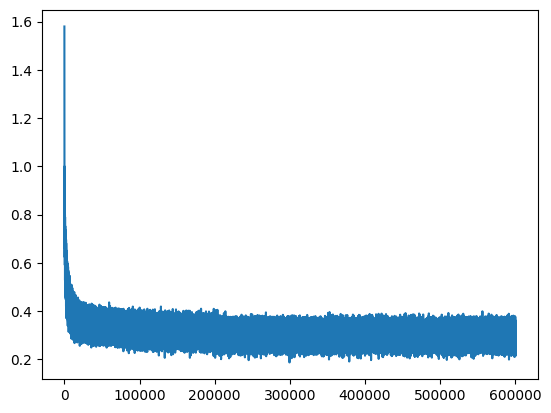

In [365]:
# Viewing the loss over steps

plt.plot(stepi, lossi)

In [366]:
# Calculating the loss on the dev set

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size*embed_dimension) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1323, grad_fn=<NllLossBackward0>)

In [367]:
# Calculating the loss on the test set

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size*embed_dimension) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.9988, grad_fn=<NllLossBackward0>)

## E01: Hyperparameter Tuning

embed_dimension = 10
hidden_dimension = 200
mini_batch_size = 32

300000 iterations, 0.1 lr for 200000, 0.01 lr for 100000

 - train loss: 1.9546570777893066
- dev loss: 2.1442
- test loss: 2.0728

embed_dimension = 10
hidden_dimension = 200
mini_batch_size = 64

300000 iterations, 0.1 lr for 200000, 0.01 lr for 100000
 - train loss: 2.141909122467041
- dev loss: 2.1287
- test loss: 2.0673

embed_dimension = 15
hidden_dimension = 200
mini_batch_size = 32

300000 iterations, 0.1 lr for 200000, 0.01 lr for 100000
 - train loss: 1.9217405319213867
- dev loss:    2.1371
- test loss:   2.0516

Training this for longer didn't seem to have any effect.

embed_dimension = 20
hidden_dimension = 200
mini_batch_size = 32
300000 iterations, 0.1 lr for 200000, 0.01 lr for 100000
 - train loss:  2.0419771671295166
- dev loss:   2.1459
- test loss:   2.0420

embed_dimension = 10
hidden_dimension = 300
mini_batch_size = 32
300000 iterations, 0.1 lr for 200000, 0.01 lr for 100000
 - train loss:  1.799740195274353
- dev loss:     2.1606
- test loss:    2.0655
300000 more iterations, 0.01 lr
 - train loss:  1.9542330503463745
- dev loss: 2.1610
- test loss: 2.0529

embed_dimension = 10
hidden_dimension = 300
mini_batch_size = 128
600000 iterations, 0.1 lr for 200000, 0.01 lr for 400000
 - train loss:  2.0505807399749756
- dev loss:  2.1386
- test loss:  2.0506

embed_dimension = 15
hidden_dimension = 300
mini_batch_size = 128
600000 iterations, 0.1 lr for 200000, 0.01 lr for 400000
 - train loss:  1.9096660614013672
- dev loss:     2.1323
- test loss:    1.9988


## Visualizing the Embeddings

If we have a 2D or embedding, we can visualize the embeddings.

We can note that often times, the vowels are grouped together, and the period is far away from the other characters.

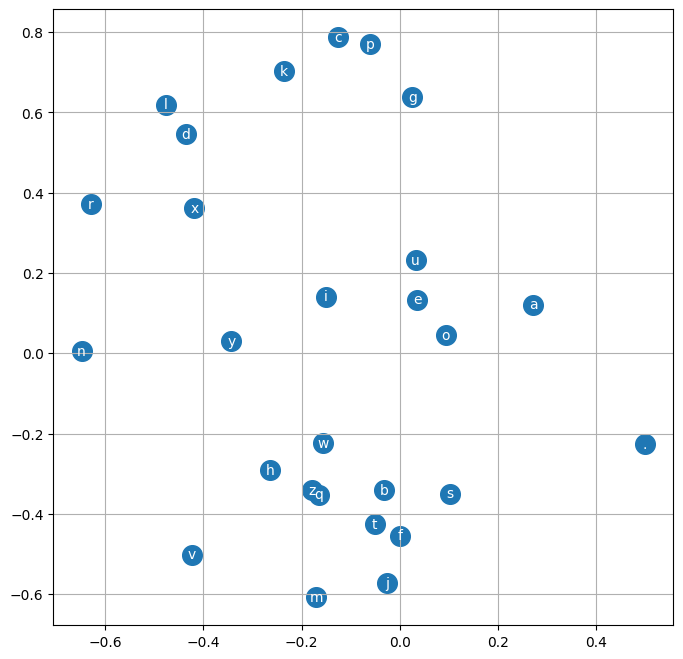

In [157]:
if embed_dimension == 2:
    plt.figure(figsize=(8, 8))
    plt.scatter(C[:,0].data, C[:,1].data, s=200)
    
    for i in range(C.shape[0]):
        plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
        
    plt.grid('minor')
    

<IPython.core.display.Javascript object>

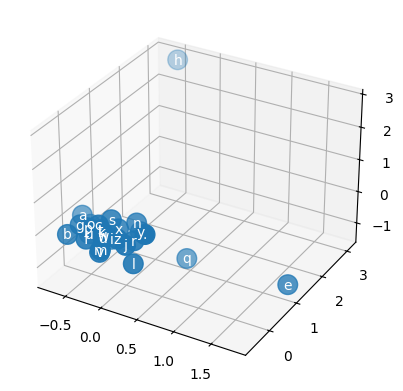

In [220]:
%matplotlib notebook
if embed_dimension == 3:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(C[:,0].data, C[:,1].data, C[:,2].data, s=200)
    
    for i in range(C.shape[0]):
        ax.text(C[i, 0].item(), C[i, 1].item(), C[i, 2].item(), itos[i], ha="center", va="center", color='white')
        
    plt.grid('minor')

## Sampling from the model

In [474]:
g = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @  W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix==0:
            break
    
    print(''.join(itos[i] for i in out))

junide.
jakaria.
presayon.
bra.
jirrito.
sabellee.
kalania.
yamilena.
jadeyah.
roy.
tayse.
yinayla.
terinleem.
kyn.
demmercentlynn.
ruter.
core.
yarion.
kaelandreed.
miki.


## E02: Initialization Experiment

If the predicted probabilities at initialization were all uniform, we would achieve a loss of:

In [8]:
loss = len(words[:n1]) * torch.log(torch.tensor(27))
loss/len(words[:n1])

# or 

loss = torch.log(torch.tensor(27))
loss

tensor(3.2958)

In [397]:
def calculcate_loss():
    emb = C[Xtr]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, block_size * embed_dimension) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr)
    return loss

For a random network, we have:

In [404]:
C = torch.randn((27, embed_dimension), generator=g)
W1 = torch.randn((block_size*embed_dimension, hidden_dimension), generator =g)
b1 = torch.randn(hidden_dimension, generator=g)
W2 = torch.randn((hidden_dimension, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

calculcate_loss()

tensor(35.6783)

For a network with all zeros, we have:

In [405]:
C = torch.zeros((27, embed_dimension))
W1 = torch.zeros((block_size*embed_dimension, hidden_dimension))
b1 = torch.zeros(hidden_dimension)
W2 = torch.zeros((hidden_dimension, 27))
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

calculcate_loss()

tensor(3.2958)

# E03: Architecture Experiment

We add the direct connections that were missing in the previous architecture.

In [444]:
# build the dataset

block_size = 4  # context length, amount of characters used to predict next one


def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


# training split, dev/validation split, test split
# 80%, 10%, 10%

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182661, 4]) torch.Size([182661])
torch.Size([22763, 4]) torch.Size([22763])
torch.Size([22722, 4]) torch.Size([22722])


In [460]:
embed_dimension = 10
hidden_dimension = 300
mini_batch_size = 32

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embed_dimension), generator=g)
W1 = torch.randn((block_size*embed_dimension, hidden_dimension), generator =g)
b1 = torch.randn(hidden_dimension, generator=g)
W2 = torch.randn((hidden_dimension + block_size*embed_dimension, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [461]:
# we use adam for optimization
adam = torch.optim.Adam(parameters)

# continue
steps = []
lossi = []

for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * embed_dimension) @ W1 + b1)
    logits = torch.cat([emb.view(emb.shape[0], -1), h], 1) @ W2 + b2  # concat the direct connections
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    adam.zero_grad()
    loss.backward()
    adam.step()

    # track stats
    steps.append(len(steps))
    lossi.append(loss.log10().item())

print(loss.item())

2.1748762130737305


In [451]:
steps = []

lossi = []


for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * embed_dimension) @ W1 + b1)
    logits = torch.cat([emb.view(emb.shape[0], -1), h], 1) @ W2 + b2  # concat the direct connections
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
        
    loss.backward()
    
    # update
    lr = 0.05 if i < 70000 else 0.01 if i < 150000 else 0.001
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    steps.append(len(steps))
    lossi.append(loss.log10().item())

print(loss.item())

2.065647602081299


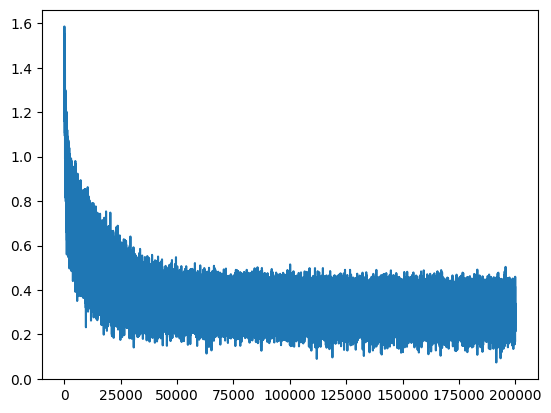

In [462]:
plt.plot(steps, lossi)

In [463]:
# Calculating the loss on the dev set

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size*embed_dimension) @ W1 + b1) 
logits = torch.cat([emb.view(emb.shape[0], -1), h], 1) @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1258, grad_fn=<NllLossBackward0>)

In [464]:
# Calculating the loss on the test set

emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size*embed_dimension) @ W1 + b1) 
logits = torch.cat([emb.view(emb.shape[0], -1), h], 1) @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1505, grad_fn=<NllLossBackward0>)

What I learned:

- Learning rate has a pretty huge effect. When testing a learning rate switch from 0.1 to 0.01, it loss went down immediately when the learning rate was switched. This indicated that 0.1 was probably too high.
- The direct connections did not seem to have an effect.
- Using Adam was easier than manually adjusting the learning rate.
- Despite increasing the block size, the loss did not seem to go down. It may require more parameters or a different architecture that can learn from the longer context.